# Phase 1 - ML Modelling

**DOLPH-X Pipeline | Master 2 MIAGE**

**Description:** Loads the LMS dataset, applies data cleaning, feature engineering, normalisation, encoding, train-test splitting and SMOTE balancing. Trains and evaluates 11 classification models. Produces the trained evaluator saved to `evaluator.pkl` for use in Phase 2 XAI notebooks.

**Input:** `cours_python__version_finale.xlsx`

**Output:** `evaluator.pkl`

## 1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

## 2. Data Loading

In [5]:
data = pd.read_excel('cours_python__version_finale.xlsx')
print(f'Dataset loaded: {data.shape[0]} students, {data.shape[1]} variables')

Dataset loaded: 128 students, 106 variables


## 3. Data Cleaning

### 3.1 Removal of Uninformative Columns

Columns are removed using a keyword-based filter targeting: administrative identifiers (Unnamed), relative rankings (RANK, DIFF_RANKING, DIFF_RATING), variables that leak the target (ENGAGEMENT, AVG_RATING), investment scores (INVESTMENT), and the TOTAL_STUDENTS_NUMBER variable which is constant across the cohort and constitutes a source of data leakage.

Constant columns (zero variance) are also removed as they carry no predictive information.

In [7]:
# Remove uninformative columns using keyword-based filter
keywords_to_drop = [
    'Unnamed',
    'RANK',
    'DIFF_RANKING',
    'DIFF_RATING',
    'TOTAL_STUDENTS',
    'INVESTMENT',
    'ENGAGEMENT',
    'AVG_RATING',
]

columns_to_drop = [
    col for col in data.columns
    if any(kw in col for kw in keywords_to_drop)
    and col not in ['DIFFICULTY', 'DIFFICULTY_encoded']
]

data.drop(columns=columns_to_drop, inplace=True)
print(f'Dropped {len(columns_to_drop)} uninformative columns')

# Remove zero-variance columns
constant_cols = [
    col for col in data.columns
    if data[col].nunique() <= 1
    and col not in ['DIFFICULTY', 'DIFFICULTY_encoded']
]
data.drop(columns=constant_cols, inplace=True)
print(f'Dropped {len(constant_cols)} constant columns')
print(f'Shape after cleaning: {data.shape}')

Dropped 52 uninformative columns
Dropped 3 constant columns
Shape after cleaning: (128, 51)


### 3.2 Timestamp Decomposition

Timestamp columns recording first and last exercise submissions per session are parsed and decomposed into six numerical components (year, month, day, hour, minute, second). Missing values are filled with -1, a sentinel value outside the natural domain of all variables, preserving the absence-of-activity signal. String columns using commas as decimal separators are converted to float.

In [9]:
# Decompose timestamp columns into 6 numerical components
liste_date_details = []
temp_dfs = []

dates = [
    'FIRST_COURSE_ACCESS', 'LAST_COURSE_ACCESS',
    'FIRST_S1Q1_EXE_SUBMISSION', 'LAST_S1Q1_EXE_SUBMISSION',
    'FIRST_S2Q1_EXE_SUBMISSION', 'LAST_S2Q1_EXE_SUBMISSION',
    'FIRST_S3Q1_EXE_SUBMISSION', 'LAST_S3Q1_EXE_SUBMISSION',
    'FIRST_S4Q1_EXE_SUBMISSION', 'LAST_S4Q1_EXE_SUBMISSION',
    'FIRST_S5Q1_EXE_SUBMISSION', 'LAST_S5Q1_EXE_SUBMISSION',
    'FIRST_S6Q1_EXE_SUBMISSION', 'LAST_S6Q1_EXE_SUBMISSION',
    'FIRST_S7Q1_EXE_SUBMISSION', 'LAST_S7Q1_EXE_SUBMISSION',
    'FIRST_S8Q1_EXE_SUBMISSION', 'LAST_S8Q1_EXE_SUBMISSION',
    'FIRST_S9Q1_EXE_SUBMISSION', 'LAST_S9Q1_EXE_SUBMISSION',
    'FIRST_S10Q1_EXE_SUBMISSION', 'LAST_S10Q1_EXE_SUBMISSION',
    'FIRST_FE_EXE_SUBMISSION', 'LAST_FE_EXE_SUBMISSION',
]

existing_dates = [d for d in dates if d in data.columns]
for date in existing_dates:
    data[date] = pd.to_datetime(data[date], errors='coerce', utc=True)
    temp_df = pd.DataFrame(index=data.index)
    temp_df[f'{date}_year']   = data[date].dt.year
    temp_df[f'{date}_month']  = data[date].dt.month
    temp_df[f'{date}_day']    = data[date].dt.day
    temp_df[f'{date}_hour']   = data[date].dt.hour
    temp_df[f'{date}_minute'] = data[date].dt.minute
    temp_df[f'{date}_second'] = data[date].dt.second
    liste_date_details.extend([
        f'{date}_year', f'{date}_month', f'{date}_day',
        f'{date}_hour', f'{date}_minute', f'{date}_second'
    ])
    temp_dfs.append(temp_df)

if temp_dfs:
    data = pd.concat([data] + temp_dfs, axis=1)
    data.drop(columns=existing_dates, inplace=True)

# Fill missing values with sentinel value -1
data.fillna(-1, inplace=True)

# Convert comma-separated string columns to float
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].astype(str).str.replace(',', '.', regex=False)
        try:
            data[col] = pd.to_numeric(data[col], errors='ignore')
        except ValueError:
            pass

print(f'Shape after feature engineering: {data.shape}')

Shape after feature engineering: (128, 171)


## 4. Feature Scaling and Train-Test Split

A stratified 80/20 train-test split is applied to preserve class proportions in both sets. StandardScaler is fitted on the training set only and applied to both sets, preventing any information leakage from the test set into the scaling parameters.

In [11]:
target_column = 'DIFFICULTY'

# Identify columns to scale
columns_to_scale = [
    col for col in data.select_dtypes(include=[np.number]).columns
    if col != target_column and col not in liste_date_details
]

# Stratified train-test split (80/20)
X = data.drop(columns=[target_column])
y = data[target_column]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_data = pd.concat([X_train, y_train], axis=1)
test_data  = pd.concat([X_test, y_test], axis=1)

df_standard_scaler_train = train_data.copy(deep=True)
df_standard_scaler_test  = test_data.copy(deep=True)

# Scale date components
date_cols_to_scale = [c for c in liste_date_details if c in df_standard_scaler_train.columns]
if date_cols_to_scale:
    date_scaler = StandardScaler()
    df_standard_scaler_train[date_cols_to_scale] = date_scaler.fit_transform(df_standard_scaler_train[date_cols_to_scale])
    df_standard_scaler_test[date_cols_to_scale]  = date_scaler.transform(df_standard_scaler_test[date_cols_to_scale])

# Scale other numeric columns
numeric_cols_to_scale = [c for c in columns_to_scale if c in df_standard_scaler_train.columns]
if numeric_cols_to_scale:
    numeric_scaler = StandardScaler()
    df_standard_scaler_train[numeric_cols_to_scale] = numeric_scaler.fit_transform(df_standard_scaler_train[numeric_cols_to_scale])
    df_standard_scaler_test[numeric_cols_to_scale]  = numeric_scaler.transform(df_standard_scaler_test[numeric_cols_to_scale])

print(f'Train set: {df_standard_scaler_train.shape}')
print(f'Test set : {df_standard_scaler_test.shape}')
print('StandardScaler applied (fitted on training set only)')

Train set: (102, 171)
Test set : (26, 171)
StandardScaler applied (fitted on training set only)


## 5. Categorical Encoding

Label Encoding is applied to the target variable DIFFICULTY. One-Hot Encoding is applied to categorical features (PUBLIC, COURSE_NAME, ACADEMIC_Y). All encoders are fitted on the training set and applied to both sets using the same categories, ensuring consistency between train and test.

In [13]:
# Label Encoding for the target variable DIFFICULTY
label_encoders = {}
for elem in ['DIFFICULTY']:
    if elem in df_standard_scaler_train.columns:
        encoder = LabelEncoder()
        encoder.fit(df_standard_scaler_train[elem].dropna().unique())
        label_encoders[elem] = encoder

        df_standard_scaler_train[elem + '_encoded'] = encoder.transform(df_standard_scaler_train[elem])
        df_standard_scaler_train.drop(columns=[elem], inplace=True)

        if elem in df_standard_scaler_test.columns:
            test_values = df_standard_scaler_test[elem].copy()
            unseen = ~test_values.isin(encoder.classes_)
            if unseen.any():
                test_values.loc[unseen] = pd.Series(encoder.classes_).mode()[0]
                print(f'Warning: {unseen.sum()} unseen values replaced in test set for {elem}')
            df_standard_scaler_test[elem + '_encoded'] = encoder.transform(test_values)
            df_standard_scaler_test.drop(columns=[elem], inplace=True)

# One-Hot Encoding for categorical features
one_hot_encoders = {}
categorical_cols = ['PUBLIC', 'COURSE_NAME', 'ACADEMIC_Y']

for elem in categorical_cols:
    if elem in df_standard_scaler_train.columns:
        one_hot_encoders[elem] = sorted(df_standard_scaler_train[elem].dropna().unique())

for elem in categorical_cols:
    if elem in df_standard_scaler_train.columns:
        ohe = pd.get_dummies(df_standard_scaler_train[elem], prefix=elem)
        for val in one_hot_encoders[elem]:
            if f'{elem}_{val}' not in ohe.columns:
                ohe[f'{elem}_{val}'] = 0
        df_standard_scaler_train = pd.concat([df_standard_scaler_train, ohe], axis=1)
        df_standard_scaler_train.drop(columns=[elem], inplace=True)

    if elem in df_standard_scaler_test.columns:
        ohe = pd.get_dummies(df_standard_scaler_test[elem], prefix=elem)
        expected = [f'{elem}_{val}' for val in one_hot_encoders.get(elem, [])]
        ohe = ohe.reindex(columns=expected, fill_value=0)
        df_standard_scaler_test = pd.concat([df_standard_scaler_test, ohe], axis=1)
        df_standard_scaler_test.drop(columns=[elem], inplace=True)

print('Encoding complete')
print(f'Train set: {df_standard_scaler_train.shape}')
print(f'Test set : {df_standard_scaler_test.shape}')

Encoding complete
Train set: (102, 174)
Test set : (26, 174)


## 6. Class Distribution and SMOTE Balancing

Before training any model, it is essential to examine how the four target profiles (E+P+, E+P-, E-P+, E-P-) are distributed across the dataset. An imbalanced distribution can silently bias a classifier toward majority classes, producing artificially high accuracy while systematically failing on minority profiles.

In our dataset, the E-P+ profile (disengaged but high-performing students) is the most represented at 35.2%, while the E+P- profile (engaged but low-performing students) is the least represented at only 14.8%. This imbalance is not a data quality issue, but rather a genuine pedagogical reality. It must still be addressed before training, otherwise the model would learn to predict the majority classes more confidently at the expense of minority ones.

**Why SMOTE.** Synthetic Minority Over-sampling Technique (SMOTE) addresses this imbalance by generating synthetic examples for minority classes rather than simply duplicating existing ones. For each minority instance, SMOTE selects its k nearest neighbours in the feature space and creates new synthetic points by interpolating between them.

**Why only on the training set.** SMOTE is applied exclusively to the training set, after the stratified train-test split. Applying it before splitting would leak synthetic information derived from test instances into the training process, artificially inflating evaluation metrics.

**Why k_neighbors=3.** The default SMOTE configuration uses k_neighbors=5, requiring at least 6 instances of the minority class in the training set. With only 15 E+P- students in the training set, k=5 would be unstable. Reducing k_neighbors to 3 provides a safer margin while still generating meaningful synthetic samples.

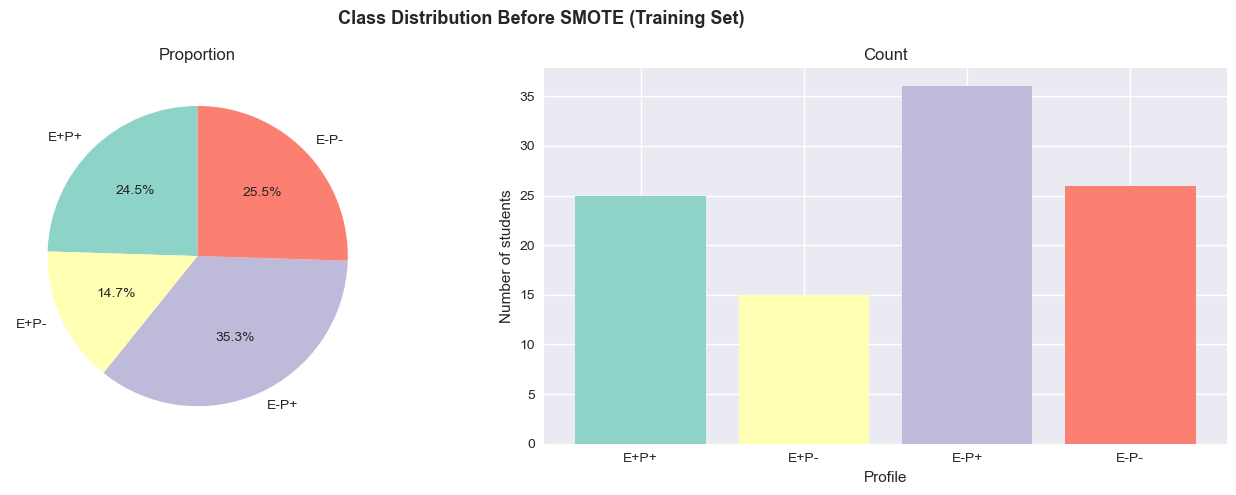

Class distribution before SMOTE:
  E+P+: 25 students (24.5%)
  E+P-: 15 students (14.7%)
  E-P+: 36 students (35.3%)
  E-P-: 26 students (25.5%)


In [33]:
# Visualise class distribution before SMOTE
profile_names = {0: 'E+P+', 1: 'E+P-', 2: 'E-P+', 3: 'E-P-'}
colors = sns.color_palette('Set3')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution Before SMOTE (Training Set)', fontsize=13, fontweight='bold')

counts_before = df_standard_scaler_train['DIFFICULTY_encoded'].value_counts().sort_index()
labels = [profile_names.get(i, str(i)) for i in counts_before.index]

axes[0].pie(counts_before.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Proportion')

axes[1].bar(labels, counts_before.values, color=colors[:len(counts_before)])
axes[1].set_title('Count')
axes[1].set_xlabel('Profile')
axes[1].set_ylabel('Number of students')

plt.tight_layout()
plt.show()

print('Class distribution before SMOTE:')
for idx, count in counts_before.items():
    pct = count / len(df_standard_scaler_train) * 100
    print(f'  {profile_names.get(idx, idx)}: {count} students ({pct:.1f}%)')

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Training set before SMOTE: 102 samples
Training set after SMOTE : 144 samples


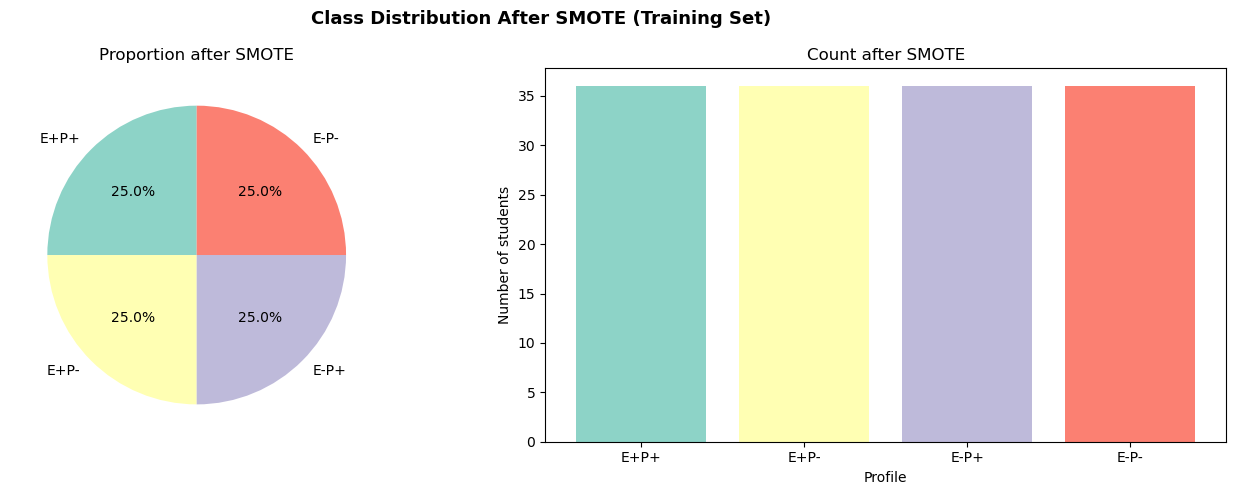

In [16]:
# Apply SMOTE to training data only
X_train_raw = df_standard_scaler_train.drop(columns=['DIFFICULTY_encoded'])
y_train_raw = df_standard_scaler_train['DIFFICULTY_encoded']

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train_raw, y_train_raw)

df_smote_train = pd.DataFrame(X_train_smote, columns=X_train_raw.columns)
df_smote_train['DIFFICULTY_encoded'] = y_train_smote

# Test set remains unchanged
df_test = df_standard_scaler_test.copy()

print(f'Training set before SMOTE: {len(y_train_raw)} samples')
print(f'Training set after SMOTE : {len(y_train_smote)} samples')

# Visualise class distribution after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution After SMOTE (Training Set)', fontsize=13, fontweight='bold')

counts_after = pd.Series(y_train_smote).value_counts().sort_index()
labels_after = [profile_names.get(i, str(i)) for i in counts_after.index]

axes[0].pie(counts_after.values, labels=labels_after, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Proportion after SMOTE')

axes[1].bar(labels_after, counts_after.values, color=colors[:len(counts_after)])
axes[1].set_title('Count after SMOTE')
axes[1].set_xlabel('Profile')
axes[1].set_ylabel('Number of students')

plt.tight_layout()
plt.show()

## 7. ML Model Training

The MLEvaluator trains and evaluates all 11 classification models on the SMOTE-balanced training set and evaluates them on the original unmodified test set. The trained evaluator is automatically saved to `evaluator.pkl` for use in the XAI notebooks.

In [18]:
from MLEvaluator import MLEvaluator

evaluator = MLEvaluator(df_smote_train, df_test)
results   = evaluator.train_and_evaluate_all()

Lancement de l'évaluation des modèles...
Préparation des données...
Données prêtes !
   Features : 169 colonnes
   Train    : 144 lignes
   Test     : 26 lignes
   Classes  : [0, 1, 2, 3]

Initialisation des modèles...
11 modèles initialisés

Entraînement de SVM...
   Accuracy  : 0.6538
   Precision : 0.6383
   Recall    : 0.6538
   F1-Score  : 0.6410
   AUC-ROC   : 0.9112

Entraînement de Logistic_Regression...
   Accuracy  : 0.6154
   Precision : 0.6217
   Recall    : 0.6154
   F1-Score  : 0.6091
   AUC-ROC   : 0.8639

Entraînement de Decision_Tree...
   Accuracy  : 0.5769
   Precision : 0.6748
   Recall    : 0.5769
   F1-Score  : 0.5991
   AUC-ROC   : 0.7863

Entraînement de KNN...
   Accuracy  : 0.6154
   Precision : 0.6192
   Recall    : 0.6154
   F1-Score  : 0.6120
   AUC-ROC   : 0.7813

Entraînement de Naive_Bayes...
   Accuracy  : 0.6538
   Precision : 0.6904
   Recall    : 0.6538
   F1-Score  : 0.6204
   AUC-ROC   : 0.8124

Entraînement de Random_Forest...
   Accuracy  : 0.730

## 8. Confusion Matrix Analysis

Confusion matrices for the two primary black-box models retained for XAI analysis in Phase 2.

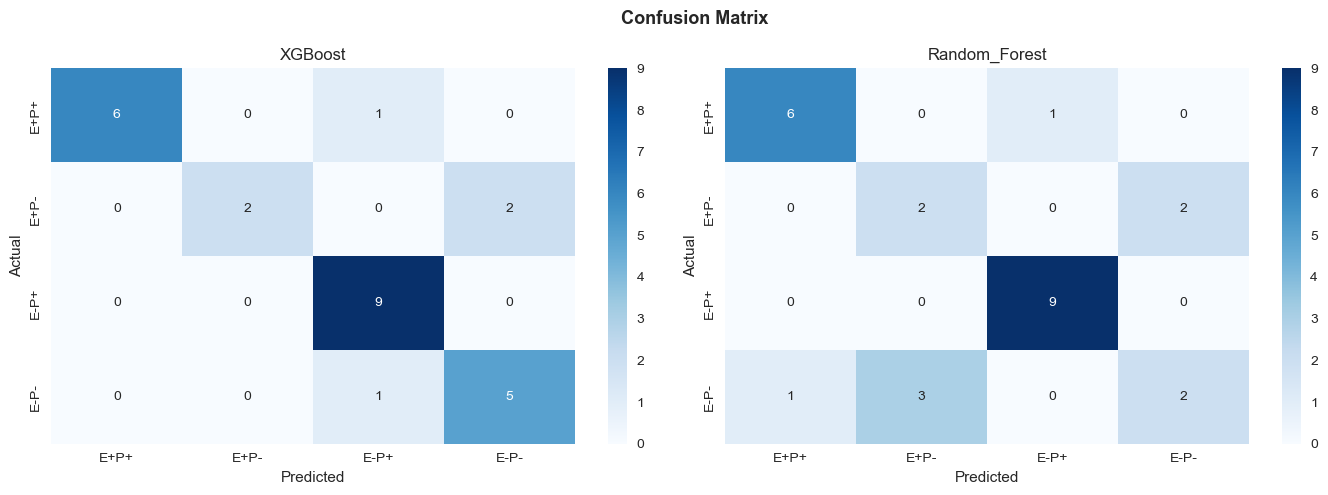

In [43]:
from sklearn.metrics import confusion_matrix

profile_names = {0: 'E+P+', 1: 'E+P-', 2: 'E-P+', 3: 'E-P-'}
labels_order  = ['E+P+', 'E+P-', 'E-P+', 'E-P-']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix', fontsize=13, fontweight='bold')

for ax, model_name in zip(axes, ['XGBoost', 'Random_Forest']):
    cm = confusion_matrix(
        evaluator.y_test,
        evaluator.all_predictions[model_name]
    )
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels_order, yticklabels=labels_order, ax=ax
    )
    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

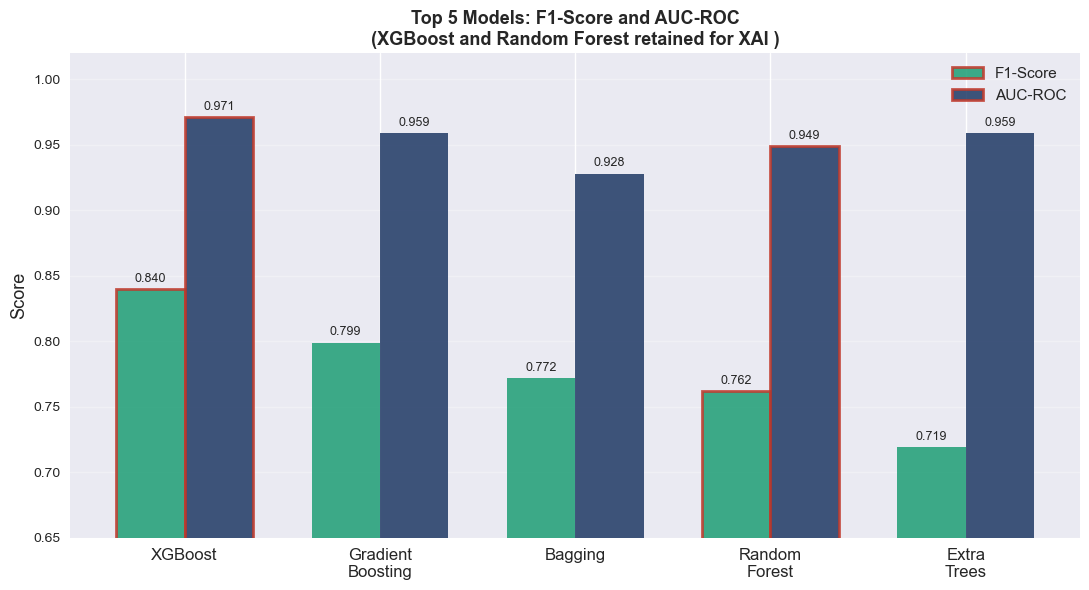

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs('outputs/canva', exist_ok=True)

models = ['XGBoost', 'Gradient\nBoosting', 'Bagging', 'Random\nForest', 'Extra\nTrees']
f1     = [0.840, 0.799, 0.772, 0.762, 0.719]
auc    = [0.971, 0.959, 0.928, 0.949, 0.959]
x, w   = np.arange(len(models)), 0.35

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - w/2, f1,  w, label='F1-Score', color='#1D9E75', alpha=0.85)
b2 = ax.bar(x + w/2, auc, w, label='AUC-ROC',  color='#1F3864', alpha=0.85)
for bar in [b1[0], b2[0], b1[3], b2[3]]:
    bar.set_edgecolor('#C0392B'); bar.set_linewidth(2)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0.65, 1.02); ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Top 5 Models: F1-Score and AUC-ROC\n(XGBoost and Random Forest retained for XAI )',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/canva/fig_top5_models.png', dpi=200, bbox_inches='tight')
plt.show()